In [4]:
devtools::load_all("/home/tangyh/script/Modsite")

ℹ Loading modsite


In [5]:
load("/home/tangyh/script/Modsite/modsite.Rcheck/m.RData")

In [6]:
annotator <- new_genomic_annotator(
  gtf_file = "/home/tangyh/reference/Homo_sapiens.GRCh38.113.gtf"
)
merged_ann <- annotate_genomic_regions(annotator, m$merged_data)

Loading GTF and building TxDb: Homo_sapiens.GRCh38.113.gtf

Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK

Importing GTF for gene metadata ...

Pre-extracting transcript features ...

Building transcript-to-gene mapping ...

'select()' returned 1:1 mapping between keys and columns

Annotator ready in 175.3 s.

Annotating 1,255 sites ...

  Annotating 5'UTR ...

  Annotating CDS ...

  Annotating 3'UTR ...

  Annotating exon ...

  Annotating intron ...

Annotation complete in 2.6 s.

-------------------------------------------------------

Genomic region summary:

  intron               420  ( 33.5%)

  intergenic           334  ( 26.6%)

  exon                 331  ( 26.4%)

  3'UTR                 61  (  4.9%)

  CDS 

In [6]:
merged_ann

ERROR: Error: object 'merged_ann' not found


In [7]:
mod_file <- system.file("extdata", "RMBase_v3_human.csv", package = "modsite")
mod_ann <- new_mod_annotator(mod_file)

Loading known modification file: RMBase_v3_human.csv

Loaded 1,377 known site(s) on 39 chromosome(s) in 0.1 s.



In [8]:
merged_ann <- annotate_known_mods(mod_ann, merged_ann)

Checking 1,255 site(s) against known modifications ...

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': HG2236_PATCH, HSCHR22_1_CTG3, HSCHR6_MHC_MANN_CTG1, HSCHR6_MHC_MCF_CTG1, MT
  - in 'y': KI270857.1, GL000251.2, GL000256.2, GL000252.2, GL000250.2, GL000255.2, GL000253.2, GL000254.2, KZ559112.1, KI270867.1, KI270765.1, KI270713.1
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”
Done in 0.0 s.

-------------------------------------------------------

Known modification summary:

  Total sites     : 1,255

  Known mod sites : 38  (3.0%)

  Other sites     : 1,217  (97.0%)

  Modification types:

    Y                    38

-------------------------------------------------------



In [9]:
known_hits <- merged_ann[merged_ann$is_known_mod, 
  c("chrom", "pos", "strand", "is_known_mod", "mod_id", "mod_type")
]
known_hits

,chrom,pos,strand,is_known_mod,mod_id,mod_type
,<chr>,<int>,<chr>,<lgl>,<chr>,<chr>
63,1,145287821,+,TRUE,Pseudo_site_340,Y
75,1,161523865,-,TRUE,Pseudo_site_494,Y
107,1,237603173,+,TRUE,Pseudo_site_607,Y
108,1,237603195,+,TRUE,Pseudo_site_608,Y
109,1,237603202,+,TRUE,Pseudo_site_609,Y
110,1,237603204,+,TRUE,Pseudo_site_610,Y
115,1,248874260,+,TRUE,Pseudo_site_630,Y
116,1,248874301,+,TRUE,Pseudo_site_632,Y
222,11,77886594,+,TRUE,Pseudo_site_969,Y


In [ ]:
#if no strand specific
'''
merged_ann_nostrand <- annotate_genomic_regions(
  annotator,
  m$merged_data,
  strand_col = ".__no_strand__"
)
''''

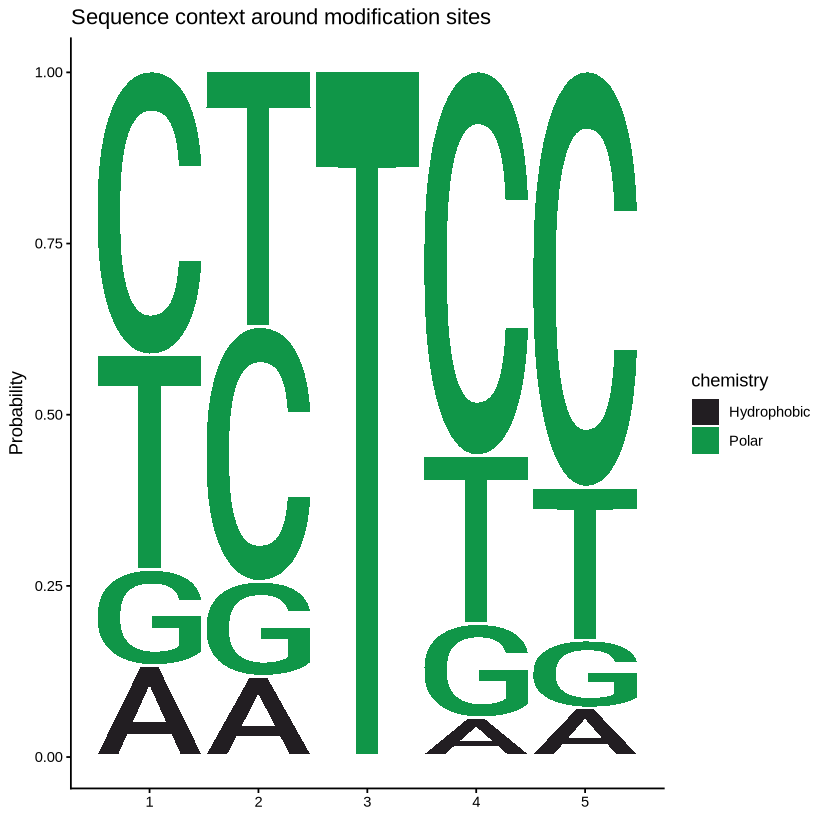

In [12]:
sequences <- merged_ann$motif
ggseqlogo(sequences, method = "prob") +
  ggplot2::theme_classic() +
  ggplot2::ggtitle("Sequence context around modification sites")


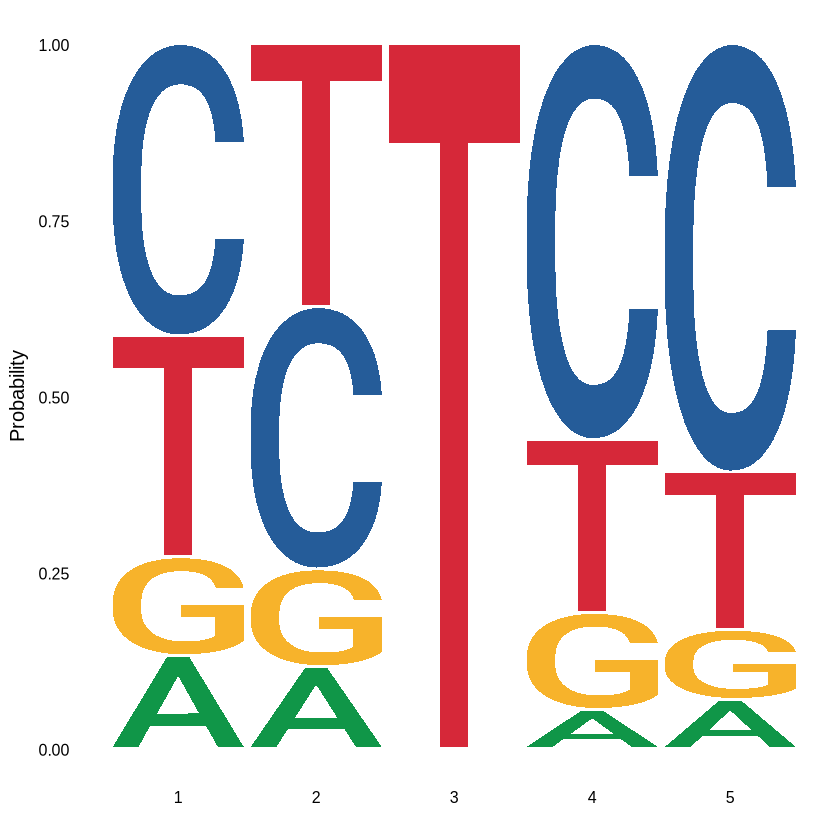

In [18]:
ggseqlogo(sequences, method = "probability", seq_type = "dna")


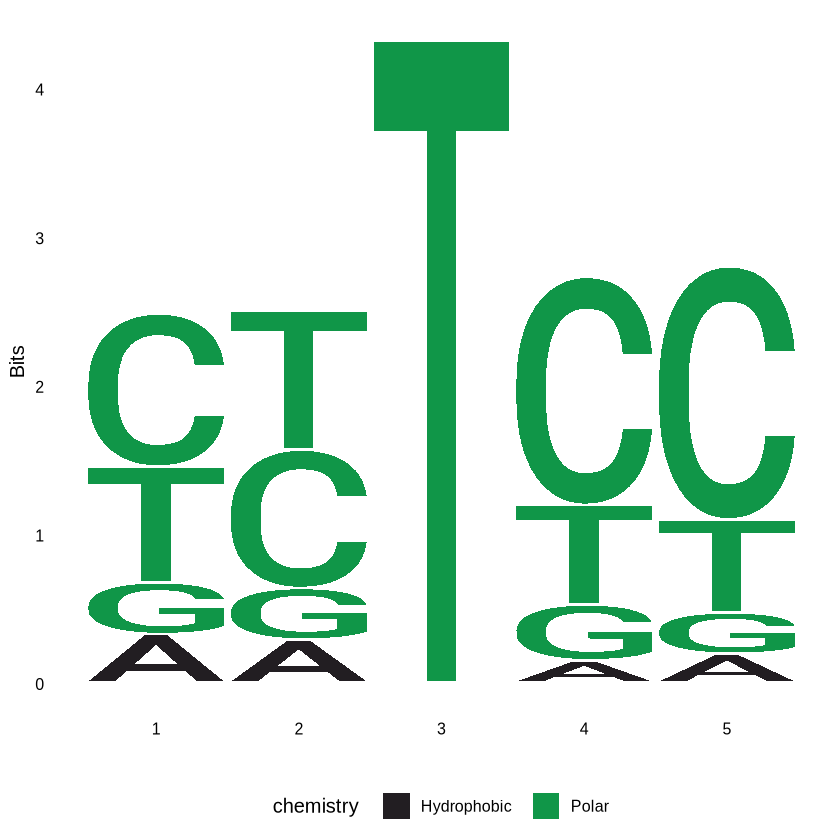

In [14]:
ggseqlogo(sequences)

In [3]:
annotator <- new_genomic_annotator(
  gtf_file = "/home/tangyh/reference/Homo_sapiens.GRCh38.113.gtf"
)

Loading GTF and building TxDb: Homo_sapiens.GRCh38.113.gtf

Warning message in call_fun_in_txdbmaker("makeTxDbFromGFF", ...):
“makeTxDbFromGFF() has moved to the txdbmaker package. Please call
  txdbmaker::makeTxDbFromGFF() to get rid of this warning.”
Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK

Importing GTF for gene metadata ...

Pre-extracting transcript features ...

Building transcript-to-gene mapping ...

'select()' returned 1:1 mapping between keys and columns

Annotator ready in 187.4 s.



In [5]:
sites_df <- as.data.table(m$merged_data)[, .(chrom, pos, strand)]
mg <- new_metagene_analyzer(
  annotator = annotator,
  sites_df = sites_df,
  n_bins = 50L
)
mg <- calc_metagene_profile(mg, smooth = TRUE, span = 0.3)
plot_metagene(mg, title = "Metagene weighted site count")

ERROR: Error in new_metagene_analyzer(annotator = annotator, sites_df = m$merged_data, : could not find function "new_metagene_analyzer"


In [4]:
annotator <- new_genomic_annotator(
  gtf_file = "/home/tangyh/reference/Homo_sapiens.GRCh38.113.gtf"
)
mg <- new_metagene_analyzer(
  annotator    = annotator,
  annotated_df = m$merged_data,
  n_bins       = 50L
)
profile <- calc_metagene_profile(mg)
plot_metagene(profile, title = "metagene – PUMseq")

Loading GTF and building TxDb: Homo_sapiens.GRCh38.113.gtf

Warning message in call_fun_in_txdbmaker("makeTxDbFromGFF", ...):
“makeTxDbFromGFF() has moved to the txdbmaker package. Please call
  txdbmaker::makeTxDbFromGFF() to get rid of this warning.”
Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK

Importing GTF for gene metadata ...

Pre-extracting transcript features ...

Building transcript-to-gene mapping ...

'select()' returned 1:1 mapping between keys and columns

Annotator ready in 174.4 s.

Initialising MetageneAnalyzer: 37 sample(s), 50 bins, strategy = median

Mapping sites to transcript coordinates...



Computing metagene profile (binning + smoothing)...

Done.



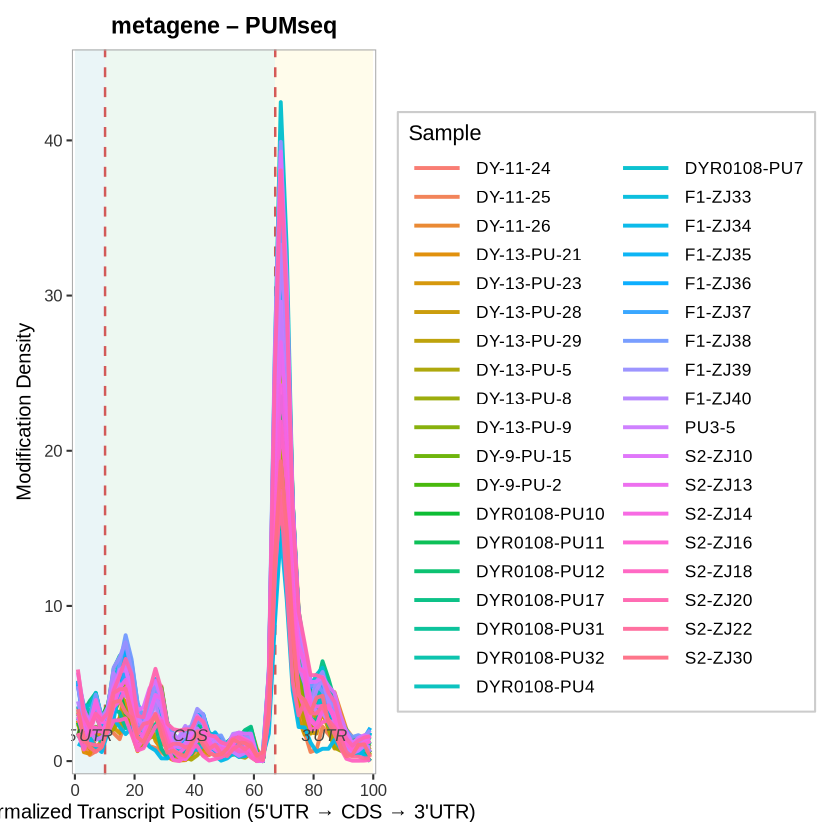

In [5]:
profile <- calc_metagene_profile(mg)
plot_metagene(profile, title = "metagene – PUMseq")

In [ ]:
mg_overall <- calc_metagene_profile(
  mg,
  profile_mode = "overall",
  metric = "count",
  smooth = TRUE,
  span = 0.4
)
p_overall <- plot_metagene(
  mg_overall,
  title = "Overall metagene site density"
)
print(p_overall)
head(mg_overall$profile_data)

In [3]:
calc_metagene_profile

function(analyzer,
                                  profile_mode = NULL,
                                  metric = c("count", "weighted_signal", "mean_rate"),
                                  smooth = TRUE, span = 0.3) {
  if (!inherits(analyzer, "MetageneAnalyzer"))
    stop("`analyzer` must be a MetageneAnalyzer object.")
  if (is.null(analyzer$mapped_res))
    stop("No mapped data available. Check that sites were mapped successfully.")

  metric <- match.arg(metric)
  profile_mode <- .resolve_metagene_profile_mode(
    profile_mode = profile_mode,
    sample_cols = analyzer$sample_cols,
    sample_groups = analyzer$sample_groups
  )

  if (profile_mode %in% c("sample", "group", "both") &&
      length(analyzer$sample_cols) == 0L) {
    stop("Selected `profile_mode` requires available sample columns.", call. = FALSE)
  }

  message("Computing metagene profile (binning + smoothing)...")

  profile_dt <- .calculate_profile_dt(
    mapped_res         = analyzer$mapped_res,
    bin_number         = analyzer$n_bins,
    sample_cols        = analyzer$sample_cols,
    profile_mode       = profile_mode,
    metric             = metric,
    sample_groups      = analyzer$sample_groups,
    aggregation_method = analyzer$aggregation_method,
    smooth             = smooth,
    span               = span
  )

  if (!is.null(profile_dt))
    profile_dt[, position := position * 100]

  analyzer$profile_data <- as.data.frame(profile_dt)
  analyzer$profile_mode <- profile_mode
  analyzer$metric <- metric
  message("Done.")
  analyzer
}
<environment: namespace:modsite>

In [6]:
ss <- new_sample_stats(merged_ann)
# Overall per-sample summary
sample_summary_stats(ss)

# Per-chromosome breakdown
head(chromosome_stats(ss))

# Per-genomic-region breakdown
genomic_region_stats(ss)

# Modification rate distribution
modification_rate_bin_stats(ss)

sample,total_sites,valid_sites,missing_sites,missing_percentage,above_threshold_sites,above_threshold_percentage,modified_sites,modified_percentage,mean_mod_rate,⋯,max_mod_rate,q25_mod_rate,q75_mod_rate,mean_mod_rate_above_threshold,mean_depth,median_depth,zero_sites,low_mod_sites,mid_mod_sites,high_mod_sites
<chr>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>
DY-11-24,7344,5854,1490,20.28867,3687,62.98258,3687,62.98258,0.17356824,⋯,1,0.00,0.16354360,0.2755814,107.43987,36,2167,1509,1469,709
DY-11-25,7344,4180,3164,43.08279,1109,26.53110,1109,26.53110,0.09654171,⋯,1,0.00,0.05555556,0.3638813,74.20598,25,3071,343,459,307
DY-11-26,7344,5694,1650,22.46732,4022,70.63576,4022,70.63576,0.18723317,⋯,1,0.00,0.18327465,0.2650685,84.79101,30,1672,1606,1709,707
DY-13-PU-21,7344,3390,3954,53.83987,2092,61.71091,2092,61.71091,0.19185236,⋯,1,0.00,0.20000000,0.3108889,49.73481,19,1298,767,866,459
DY-13-PU-23,7344,4077,3267,44.48529,2364,57.98381,2364,57.98381,0.16065378,⋯,1,0.00,0.16129032,0.2770666,52.47339,21,1713,945,996,423
DY-13-PU-28,7344,4607,2737,37.26852,3045,66.09507,3045,66.09507,0.19967868,⋯,1,0.00,0.21428571,0.3021083,56.81441,23,1562,1072,1338,635
DY-13-PU-29,7344,3379,3965,53.98965,2310,68.36342,2310,68.36342,0.21426441,⋯,1,0.00,0.24015504,0.3134197,64.46967,19,1069,748,1047,515
DY-13-PU-5,7344,2520,4824,65.68627,1677,66.54762,1677,66.54762,0.24467913,⋯,1,0.00,0.31578947,0.3676753,69.92738,17,843,531,665,481
DY-13-PU-8,7344,5204,2140,29.13943,2904,55.80323,2904,55.80323,0.16185407,⋯,1,0.00,0.15427350,0.2900443,67.77921,25,2300,1139,1179,586


,sample,chrom,total_sites,valid_sites,above_threshold_sites,modified_sites,mean_mod_rate,mean_mod_rate_above_threshold,mean_depth,percentage
,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
1,DY-11-24,1,656,531,345,345,0.2081587,0.3203833,76.19397,8.932462
2,DY-11-24,10,308,244,171,171,0.1810682,0.2583663,53.24590,4.193900
3,DY-11-24,11,420,331,193,193,0.1741652,0.2986978,125.67674,5.718954
4,DY-11-24,12,441,356,222,222,0.1695480,0.2718877,62.58146,6.004902
5,DY-11-24,13,104,89,49,49,0.1030427,0.1871592,50.40449,1.416122
6,DY-11-24,14,234,190,122,122,0.1569375,0.2444108,123.60526,3.186275


sample,genomic_region,total_sites,valid_sites,above_threshold_sites,modified_sites,mean_mod_rate,mean_mod_rate_above_threshold,mean_depth,percentage
<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
DY-11-24,3'UTR,1035,899,491,491,0.11550357,0.2114821,77.85317,14.093137
DY-11-24,5'UTR,409,290,154,154,0.11562103,0.2177279,71.16552,5.569172
DY-11-24,CDS,865,673,323,323,0.10089308,0.2102199,256.74889,11.778322
DY-11-24,exon,923,738,566,566,0.27572971,0.3595204,198.01626,12.568083
DY-11-24,intergenic,1058,725,528,528,0.34616165,0.4753167,102.90345,14.406318
DY-11-24,intron,3054,2529,1625,1625,0.14090309,0.2192886,57.25267,41.584967
DY-11-25,3'UTR,1035,813,144,144,0.07613040,0.4298196,45.47724,14.093137
DY-11-25,5'UTR,409,222,37,37,0.07886819,0.4732091,36.20270,5.569172
DY-11-25,CDS,865,500,81,81,0.08402302,0.5186606,153.22200,11.778322


sample,mod_rate_bin,count,percentage
<chr>,<chr>,<int>,<dbl>
DY-11-24,0-0.1,3676,62.794670
DY-11-24,0.1-0.3,1182,20.191322
DY-11-24,0.3-0.5,287,4.902631
DY-11-24,0.5-0.7,175,2.989409
DY-11-24,0.7-1,534,9.121968
DY-11-25,0-0.1,3414,81.674641
DY-11-25,0.1-0.3,311,7.440191
DY-11-25,0.3-0.5,148,3.540670
DY-11-25,0.5-0.7,81,1.937799
